# Atividade 03 — Identificação de Sistemas Não-Lineares

**Disciplina:** ECOM-121 — Introdução à Identificação de Sistemas (UFAL, 2026.1)

Este notebook implementa três métodos de identificação de sistemas não-lineares baseados em modelos **NARX** (Nonlinear AutoRegressive with eXogenous input), aplicados a quatro benchmarks clássicos:

| # | Dataset | Samples | Ts |
|---|---------|---------|----|
| 1 | **Silverbox** (oscilador de Duffing elétrico) | 131 072 | ~7.8 µs |
| 2 | **Wiener-Hammerstein** (banco de filtros + não-linearidade estática) | 188 000 | ~19.5 µs |
| 3 | **Ball and Beam** (ângulo → posição da bola) | 1 000 | 0.1 s |
| 4 | **Heat Exchanger** (vazão → temperatura de saída) | 4 000 | 1 s |

---
## Métodos implementados

### 1. FROLS — *Forward Regression Orthogonal Least Squares* (Chen *et al.*, 1989)
Seleção progressiva de termos a partir de um dicionário polinomial de candidatos, usando ortogonalização de Gram-Schmidt clássica. Cada termo adicionado maximiza a razão de redução de erro (**ERR**).  

### 2. MGS — *Modified Gram-Schmidt* (variante numérica do FROLS)
Idêntico ao FROLS em termos de seleção de termos, porém a ortogonalização é feita pelo algoritmo de Gram-Schmidt **Modificado** (atualização in-place dos candidatos restantes), que é numericamente mais estável do que a versão clássica.

### 3. SEMP — *Simulation Error Minimization with Pruning* (Piroddi & Spinelli, 2003)
Parte de um modelo inicial (obtido por FROLS) e minimiza o **erro de simulação livre** (multi-passo) via otimização não-linear, seguida de poda iterativa de termos com contribuição desprezível.

---
**Modelo NARX polinomial:**  
$$y(k) = \sum_{i} \theta_i \cdot \varphi_i\bigl(y(k-1),\ldots,y(k-n_y),\,u(k-1),\ldots,u(k-n_u)\bigr) + e(k)$$
onde cada $\varphi_i$ é um monômio de grau $\leq \ell$ nas variáveis de atraso.

## 1. Importações e configurações globais

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import io as sio
from scipy.optimize import minimize
from itertools import combinations_with_replacement
import warnings
import time

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.4,
    'font.size': 10,
})

DATA_PATH = '.'  # notebook is inside 'Atividade 03/'
print('Imports OK.')

Imports OK.


## 2. Carregamento e pré-processamento dos dados

In [2]:
# ──────────────────────────────────────────────────────────────
#  Ball and Beam  (1 000 amostras, Ts = 0.1 s)
# ──────────────────────────────────────────────────────────────
bb_raw = np.loadtxt('ballbeam.dat')
u_bb_full = bb_raw[:, 0]   # ângulo do feixe  [rad]
y_bb_full = bb_raw[:, 1]   # posição da bola  [m]

# ──────────────────────────────────────────────────────────────
#  Heat Exchanger  (4 000 amostras, Ts = 1 s)
#  Colunas: time | input q | output th
# ──────────────────────────────────────────────────────────────
ex_raw = np.loadtxt('exchanger.dat')
u_ex_full = ex_raw[:, 1]   # vazão  [m³/h]
y_ex_full = ex_raw[:, 2]   # temperatura de saída [°C]

# ──────────────────────────────────────────────────────────────
#  Silverbox  (~131 k amostras)
#  CSV colunas: V1 (entrada), V2 (saída)
#  Usamos subset: primeiras 8 000 amostras para viabilidade
# ──────────────────────────────────────────────────────────────
sb_csv = pd.read_csv('SilverboxFiles/SNLS80mV.csv')
u_sb_full = sb_csv['V1'].values
y_sb_full = sb_csv['V2'].values
SB_N = 8000  # subset

# ──────────────────────────────────────────────────────────────
#  Wiener-Hammerstein  (~188 k amostras)
#  CSV colunas: uBenchMark, yBenchMark
#  Usamos subset: primeiras 8 000 amostras
# ──────────────────────────────────────────────────────────────
wh_csv = pd.read_csv('WienerHammerstein2009Files/WienerHammerBenchmark.csv')
u_wh_full = wh_csv['uBenchMark'].values
y_wh_full = wh_csv['yBenchMark'].values
WH_N = 8000  # subset

print(f'Ball & Beam     : {len(u_bb_full)} amostras')
print(f'Heat Exchanger  : {len(u_ex_full)} amostras')
print(f'Silverbox       : {len(u_sb_full)} amostras (usando {SB_N})')
print(f'Wiener-Hammer.  : {len(u_wh_full)} amostras (usando {WH_N})')

Ball & Beam     : 1000 amostras
Heat Exchanger  : 4000 amostras
Silverbox       : 131072 amostras (usando 8000)
Wiener-Hammer.  : 188000 amostras (usando 8000)


In [3]:
def split_normalize(u_full, y_full, n_use=None, train_frac=0.6):
    """Corta, normaliza (z-score) e divide em treino/validação."""
    if n_use is not None:
        u_full = u_full[:n_use]
        y_full = y_full[:n_use]

    N = len(u_full)
    n_train = int(N * train_frac)

    # Estatísticas apenas no treino para evitar vazamento
    u_mean, u_std = u_full[:n_train].mean(), u_full[:n_train].std() + 1e-12
    y_mean, y_std = y_full[:n_train].mean(), y_full[:n_train].std() + 1e-12

    u_norm = (u_full - u_mean) / u_std
    y_norm = (y_full - y_mean) / y_std

    return (
        u_norm[:n_train], y_norm[:n_train],   # treino
        u_norm[n_train:], y_norm[n_train:],   # validação
        (u_mean, u_std, y_mean, y_std)
    )

datasets = {
    'Ball & Beam': split_normalize(u_bb_full, y_bb_full),
    'Heat Exchanger': split_normalize(u_ex_full, y_ex_full),
    'Silverbox': split_normalize(u_sb_full, y_sb_full, n_use=SB_N),
    'Wiener-Hammerstein': split_normalize(u_wh_full, y_wh_full, n_use=WH_N),
}

for name, (u_tr, y_tr, u_val, y_val, _) in datasets.items():
    print(f'{name:22s}  treino={len(u_tr):5d}  val={len(u_val):5d}')

Ball & Beam             treino=  600  val=  400
Heat Exchanger          treino= 2400  val= 1600
Silverbox               treino= 4800  val= 3200
Wiener-Hammerstein      treino= 4800  val= 3200


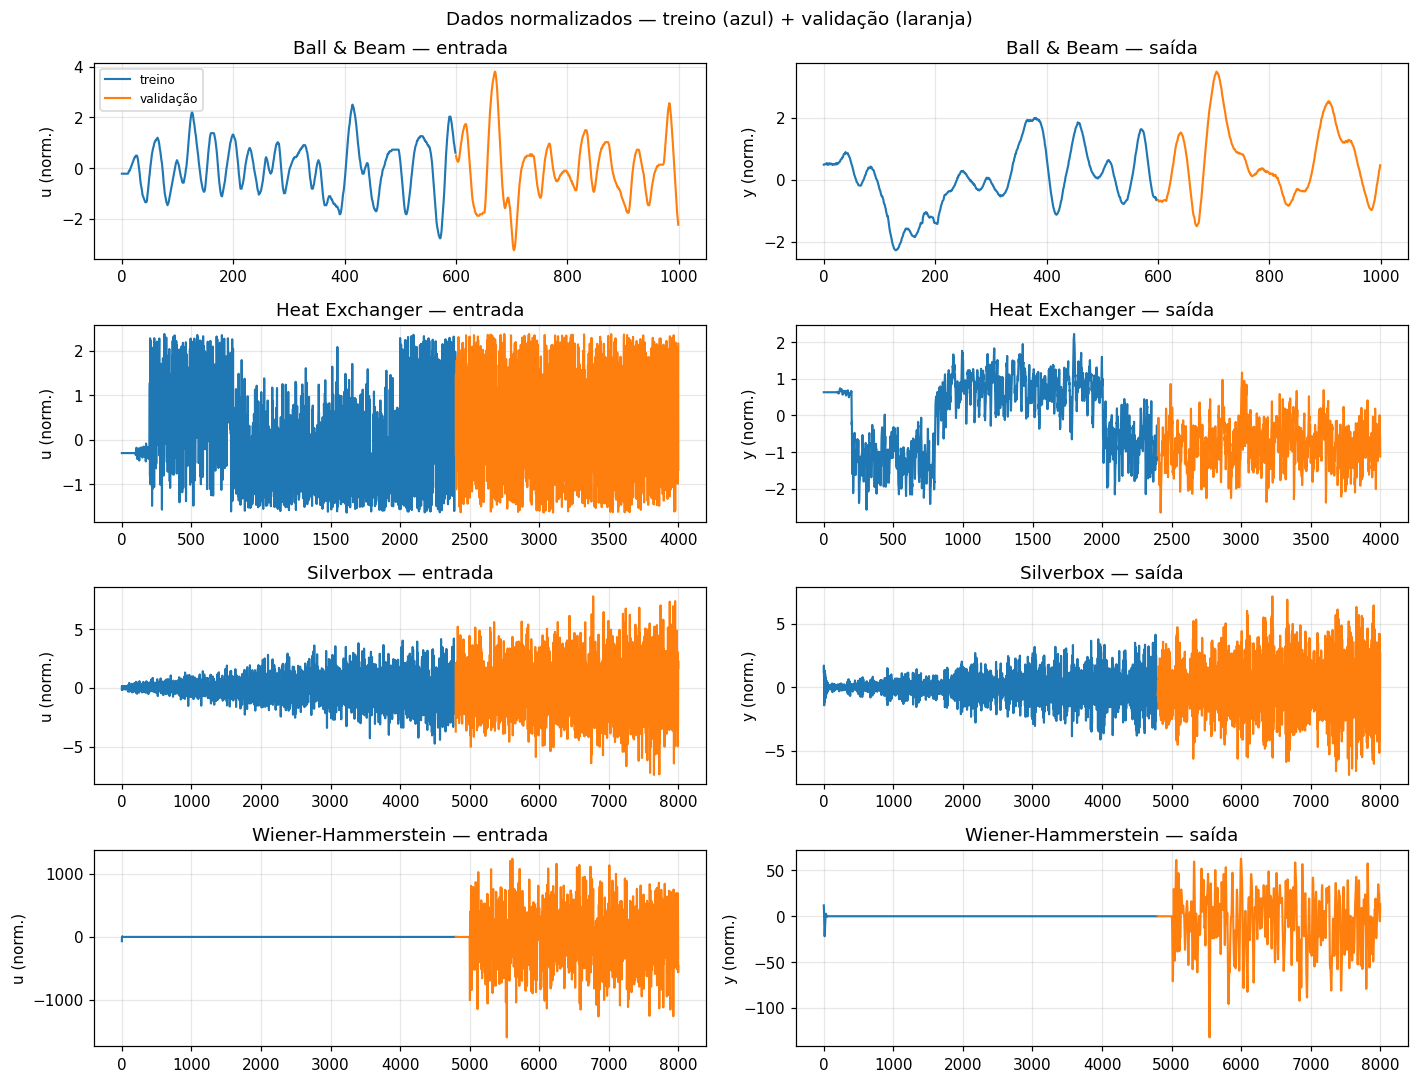

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(13, 10))
fig.suptitle('Dados normalizados — treino (azul) + validação (laranja)', fontsize=12)

for row, (name, (u_tr, y_tr, u_val, y_val, _)) in enumerate(datasets.items()):
    # entrada
    axes[row, 0].plot(u_tr, label='treino')
    axes[row, 0].plot(np.arange(len(u_tr), len(u_tr)+len(u_val)), u_val,
                      color='C1', label='validação')
    axes[row, 0].set_ylabel('u (norm.)')
    axes[row, 0].set_title(f'{name} — entrada')
    if row == 0:
        axes[row, 0].legend(fontsize=8)

    # saída
    axes[row, 1].plot(y_tr)
    axes[row, 1].plot(np.arange(len(y_tr), len(y_tr)+len(y_val)), y_val, color='C1')
    axes[row, 1].set_ylabel('y (norm.)')
    axes[row, 1].set_title(f'{name} — saída')

plt.tight_layout()
plt.show()

## 3. Utilitários para modelos NARX polinomiais

In [5]:
def gen_monomials(n_vars, degree):
    """
    Gera todos os monômios de grau 0 até `degree` sobre `n_vars` variáveis.
    Retorna lista de tuplas de índices (com repetição).
    O monômio vazio () representa o termo constante.
    """
    monomials = [()]  # grau 0 = constante
    for d in range(1, degree + 1):
        for combo in combinations_with_replacement(range(n_vars), d):
            monomials.append(combo)
    return monomials


def monomial_label(monomial, var_names):
    """Rótulo legível de um monômio."""
    if len(monomial) == 0:
        return '1'
    from collections import Counter
    cnt = Counter(monomial)
    parts = []
    for idx, exp in sorted(cnt.items()):
        if exp == 1:
            parts.append(var_names[idx])
        else:
            parts.append(f'{var_names[idx]}^{exp}')
    return '·'.join(parts)


def build_regressor_matrix(y, u, ny, nu, degree, monomials=None):
    """
    Constrói a matriz de regressores polinomiais Psi (N_eff × M).

    Parâmetros
    ----------
    y, u   : arrays de saída e entrada (N amostras)
    ny, nu : número de atrasos de y e u
    degree : grau máximo dos monômios
    monomials : se fornecido, usa apenas esses monômios

    Retorna
    -------
    Psi    : (N - max_lag, M)
    all_monomials : lista de monômios correspondentes às colunas
    var_names     : nomes das variáveis de atraso
    max_lag       : int
    """
    N = len(y)
    max_lag = max(ny, nu)
    n_eff = N - max_lag
    n_vars = ny + nu

    var_names = ([f'y(k-{i})' for i in range(1, ny + 1)] +
                 [f'u(k-{i})' for i in range(1, nu + 1)])

    # Matriz de atrasos: linhas = amostras, colunas = variáveis de atraso
    lag_mat = np.empty((n_eff, n_vars))
    for i, lag in enumerate(range(1, ny + 1)):
        lag_mat[:, i] = y[max_lag - lag: N - lag]
    for i, lag in enumerate(range(1, nu + 1)):
        lag_mat[:, ny + i] = u[max_lag - lag: N - lag]

    if monomials is None:
        monomials = gen_monomials(n_vars, degree)

    Psi = np.empty((n_eff, len(monomials)))
    for j, mono in enumerate(monomials):
        if len(mono) == 0:
            Psi[:, j] = 1.0
        else:
            vals = np.ones(n_eff)
            for idx in mono:
                vals *= lag_mat[:, idx]
            Psi[:, j] = vals

    return Psi, monomials, var_names, max_lag


def compute_phi_single(y_hist, u_hist, ny, nu, monomials):
    """
    Calcula o vetor regressor φ(k) para um único instante k,
    dado o histórico de y e u (vetores de tamanho ≥ max_lag).
    """
    lag_vars = ([y_hist[-i] for i in range(1, ny + 1)] +
                [u_hist[-i] for i in range(1, nu + 1)])
    phi = np.empty(len(monomials))
    for j, mono in enumerate(monomials):
        if len(mono) == 0:
            phi[j] = 1.0
        else:
            val = 1.0
            for idx in mono:
                val *= lag_vars[idx]
            phi[j] = val
    return phi


def simulate_narx(y_train, u_sim, theta, monomials, ny, nu,
                  clip=1e4, use_y0_from_train=True):
    """
    Simulação livre (multi-passo) do modelo NARX.

    - Os primeiros max_lag valores são inicializados a partir de `y_train`.
    - `clip` limita divergência numérica.
    """
    max_lag = max(ny, nu)
    N = len(u_sim)
    y_sim = np.zeros(N)

    if use_y0_from_train:
        y_sim[:max_lag] = y_train[:max_lag]
    else:
        y_sim[:max_lag] = 0.0

    for k in range(max_lag, N):
        phi = compute_phi_single(
            y_sim[k - ny: k],
            u_sim[k - nu: k],
            ny, nu, monomials
        )
        y_sim[k] = np.clip(phi @ theta, -clip, clip)

    return y_sim


print('Utilitários NARX OK.')

Utilitários NARX OK.


## 4. Métricas de desempenho

In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def nrmse(y_true, y_pred):
    """NRMSE = RMSE / std(y_true)  (adimensional; 0 = perfeito)"""
    return rmse(y_true, y_pred) / (np.std(y_true) + 1e-12)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1.0 - ss_res / (ss_tot + 1e-12)

def compute_metrics(y_true, y_pred, label=''):
    r = rmse(y_true, y_pred)
    nr = nrmse(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    if label:
        print(f'  [{label}]  RMSE={r:.5f}  NRMSE={nr:.4f}  R²={r2:.4f}')
    return r, nr, r2

print('Métricas OK.')

Métricas OK.


## 5. FROLS — *Forward Regression Orthogonal Least Squares* (Gram-Schmidt Clássico)

**Referência:** L. A. Chen, S. A. Billings, W. Luo, "Orthogonal least squares methods and their application to non-linear system identification", *Int. J. Control*, 50(5), 1989.

**Algoritmo:**
1. Inicializa `W = Ψ` (cópia da matriz de candidatos).
2. Em cada passo `s`:
   - Para cada candidato `j` ainda não selecionado, reortogonaliza `ψ_j` contra todos os vetores **já selecionados** `w_1,...,w_{s-1}` (GS clássico: recalcula do zero a partir de `ψ_j`).
   - Seleciona o candidato `j*` que maximiza `ERR_j = (w_j^T y)² / (w_j^T w_j · y^T y)`.
   - Atualiza a base ortogonal.
3. Para quando `Σ ERR ≥ err_threshold` ou `max_terms` selecionados.

In [7]:
def frols(Psi, y, max_terms=20, err_threshold=0.999):
    """
    FROLS com ortogonalização de Gram-Schmidt clássica.

    Parâmetros
    ----------
    Psi           : (N, M) matriz de regressores candidatos
    y             : (N,) vetor de saída
    max_terms     : número máximo de termos a selecionar
    err_threshold : parar quando ERR acumulada ≥ este valor

    Retorna
    -------
    selected_idx : lista dos índices de colunas selecionadas
    ERR_list     : ERR de cada termo selecionado
    theta        : parâmetros OLS nos termos selecionados
    """
    N, M = Psi.shape
    yTy = float(y @ y)
    if yTy < 1e-14:
        return [], [], np.array([])

    # w_basis[i] = vetor ortogonal do i-ésimo termo selecionado
    w_basis = []   # lista de vetores w_i já normalizados (divididos por ||w_i||²)
    w_raw   = []   # lista de vetores w_i originais

    selected_idx = []
    available    = list(range(M))
    ERR_list     = []
    cumulative   = 0.0

    for _ in range(min(max_terms, M)):
        best_err = -1.0
        best_j   = -1
        best_w   = None

        for j in available:
            # GS clássico: reortogonaliza ψ_j contra toda a base acumulada
            w_j = Psi[:, j].copy()
            for wr in w_raw:
                w_j -= (wr @ Psi[:, j]) / (wr @ wr) * wr

            wTw = float(w_j @ w_j)
            if wTw < 1e-14:
                continue
            err_j = (float(w_j @ y))**2 / (wTw * yTy)

            if err_j > best_err:
                best_err = err_j
                best_j   = j
                best_w   = w_j

        if best_j == -1:
            break

        selected_idx.append(best_j)
        ERR_list.append(best_err)
        cumulative += best_err
        available.remove(best_j)
        w_raw.append(best_w)

        if cumulative >= err_threshold:
            break

    # Estimativa OLS nos termos selecionados
    Psi_sel = Psi[:, selected_idx]
    theta, *_ = np.linalg.lstsq(Psi_sel, y, rcond=None)

    return selected_idx, ERR_list, theta


print('FROLS OK.')

FROLS OK.


## 6. MGS — *Modified Gram-Schmidt* (variante numérica)

Ao contrário do FROLS clássico que reortogonaliza cada candidato *do zero* em cada passo, o MGS **atualiza in-place** os vetores candidatos restantes após cada seleção:

$$q_j \leftarrow q_j - \frac{q_s^\top q_j}{q_s^\top q_s}\,q_s \quad \forall\, j \in \text{disponíveis}$$

Isso reduz o acúmulo de erros de ponto flutuante em bases com muitos termos.

In [8]:
def mgs(Psi, y, max_terms=20, err_threshold=0.999):
    """
    FROLS com ortogonalização de Gram-Schmidt Modificado.

    Parâmetros / Retorno: idênticos a `frols`.
    """
    N, M = Psi.shape
    yTy  = float(y @ y)
    if yTy < 1e-14:
        return [], [], np.array([])

    # Q: cópia trabalho — colunas serão atualizadas in-place
    Q = Psi.astype(float, copy=True)

    selected_idx = []
    available    = list(range(M))
    ERR_list     = []
    cumulative   = 0.0

    for _ in range(min(max_terms, M)):
        best_err = -1.0
        best_j   = -1

        for j in available:
            qTq = float(Q[:, j] @ Q[:, j])
            if qTq < 1e-14:
                continue
            err_j = (float(Q[:, j] @ y))**2 / (qTq * yTy)
            if err_j > best_err:
                best_err = err_j
                best_j   = j

        if best_j == -1:
            break

        selected_idx.append(best_j)
        ERR_list.append(best_err)
        cumulative += best_err
        available.remove(best_j)

        # MGS: projetar e subtrair de todos os candidatos restantes
        q_s   = Q[:, best_j].copy()
        qsTqs = float(q_s @ q_s)
        for j in available:
            Q[:, j] -= (float(q_s @ Q[:, j]) / qsTqs) * q_s

        if cumulative >= err_threshold:
            break

    Psi_sel = Psi[:, selected_idx]
    theta, *_ = np.linalg.lstsq(Psi_sel, y, rcond=None)

    return selected_idx, ERR_list, theta


print('MGS OK.')

MGS OK.


## 7. SEMP — *Simulation Error Minimization with Pruning*

**Referência:** L. Piroddi & W. Spinelli, "An identification algorithm for polynomial NARX models based on simulation error minimization", *Int. J. Control*, 76(17), 2003.

**Ideia central:** Os métodos FROLS/MGS minimizam o erro de predição *um-passo-à-frente* (1-SAP), que usa $y$ medido como condição inicial em cada passo. O SEMP vai além: minimiza o **erro de simulação livre** (erro acumulado ao longo do tempo), tornando o modelo mais adequado para uso em malha fechada ou predição de longo prazo.

**Algoritmo:**
1. **Inicialização**: estrutura inicial obtida por FROLS; parâmetros iniciais por OLS.
2. **Minimização**: otimiza $\theta$ minimizando $\|y - \hat{y}_{\text{sim}}(\theta)\|^2$ (simulação livre).
3. **Poda**: para cada termo $i$, avalia o aumento relativo do erro de simulação ao removê-lo. Remove o termo que menos prejudica o ajuste e cujo impacto relativo é $\leq$ `prune_tol`.
4. Repete os passos 2-3 até não ser possível podar mais nenhum termo.

In [9]:
def semp(y_train, u_train, initial_monomials, initial_theta,
         ny, nu, prune_tol=0.05,
         opt_method='L-BFGS-B', opt_maxiter=300,
         prune_opt_maxiter=100,
         verbose=False):
    """
    Simulation Error Minimization with Pruning (SEMP).

    Parâmetros
    ----------
    y_train, u_train  : dados de treino (N amostras)
    initial_monomials : lista de monômios (estrutura inicial, tipicamente do FROLS)
    initial_theta     : parâmetros iniciais (array 1-D)
    ny, nu            : ordens de atraso
    prune_tol         : tolerância relativa para poda  (ex: 0.05 = 5%)
    opt_method        : método de otimização para scipy.optimize.minimize
    opt_maxiter       : máximo de iterações na otimização principal
    prune_opt_maxiter : máximo de iterações na otimização de poda
    verbose           : imprimir progresso

    Retorna
    -------
    final_monomials : lista de monômios selecionados
    final_theta     : parâmetros otimizados
    history         : lista de dicts com info de cada passo
    """
    max_lag = max(ny, nu)
    y_init  = y_train[:max_lag]
    y_tgt   = y_train[max_lag:]

    current_monomials = list(initial_monomials)
    current_theta     = initial_theta.copy()
    history           = []

    def sim_loss(theta, monos):
        """Erro de simulação livre."""
        y_sim = simulate_narx(y_train, u_train, theta, monos, ny, nu)
        err   = y_sim[max_lag:] - y_tgt
        if np.any(np.isnan(err)) or np.any(np.isinf(err)):
            return 1e12
        return float(np.dot(err, err))

    step = 0
    while True:
        step += 1

        # ── Fase 1: minimização do erro de simulação ─────────────────────
        res = minimize(
            sim_loss, current_theta,
            args=(current_monomials,),
            method=opt_method,
            options={'maxiter': opt_maxiter, 'ftol': 1e-10, 'gtol': 1e-7}
        )
        current_theta = res.x
        baseline_loss = res.fun

        if verbose:
            print(f'  Passo {step}: {len(current_monomials)} termos | '
                  f'loss_sim = {baseline_loss:.6e}')

        if len(current_monomials) <= 1:
            break

        # ── Fase 2: poda ────────────────────────────────────────────────
        best_prune_i        = -1
        best_rel_increase   = np.inf
        best_pruned_theta   = None
        best_pruned_monos   = None

        for i in range(len(current_monomials)):
            test_monos = current_monomials[:i] + current_monomials[i+1:]
            test_theta = np.delete(current_theta, i)

            res_p = minimize(
                sim_loss, test_theta,
                args=(test_monos,),
                method=opt_method,
                options={'maxiter': prune_opt_maxiter, 'ftol': 1e-9, 'gtol': 1e-6}
            )
            rel_inc = (res_p.fun - baseline_loss) / (abs(baseline_loss) + 1e-10)

            if rel_inc < best_rel_increase:
                best_rel_increase = rel_inc
                best_prune_i      = i
                best_pruned_theta = res_p.x
                best_pruned_monos = test_monos

        info = dict(step=step, n_terms=len(current_monomials),
                    loss=baseline_loss, rel_inc=best_rel_increase)
        history.append(info)

        if best_rel_increase <= prune_tol:
            if verbose:
                removed = monomial_label(current_monomials[best_prune_i],
                                         [f'v{k}' for k in range(ny+nu)])
                print(f'    → Podado: termo {best_prune_i} '
                      f'(rel_inc={best_rel_increase:.3f}): {removed}')
            current_monomials = best_pruned_monos
            current_theta     = best_pruned_theta
        else:
            if verbose:
                print(f'    → Sem poda (menor aumento = {best_rel_increase:.3f} > tol={prune_tol})')
            break

    # Otimização final
    res_final = minimize(
        sim_loss, current_theta,
        args=(current_monomials,),
        method=opt_method,
        options={'maxiter': opt_maxiter * 2, 'ftol': 1e-12, 'gtol': 1e-9}
    )
    current_theta = res_final.x

    return current_monomials, current_theta, history


print('SEMP OK.')

SEMP OK.


## 8. Função de orquestração

Aplica os três métodos a um dataset e exibe resultados de forma padronizada.

In [10]:
def identify_and_compare(name, u_tr, y_tr, u_val, y_val,
                         ny=2, nu=2, degree=2,
                         max_terms=15, err_thr=0.999,
                         semp_prune_tol=0.05,
                         semp_verbose=False):
    """
    Aplica FROLS, MGS e SEMP ao dataset especificado.
    Retorna dicionário de resultados.
    """
    print(f'\n{"═"*60}')
    print(f'  Dataset: {name}  |  ny={ny}, nu={nu}, grau={degree}')
    print(f'  Treino: {len(u_tr)} amostras | Validação: {len(u_val)} amostras')
    print(f'{"═"*60}')

    # Matriz de candidatos (treino)
    Psi_tr, all_monos, var_names, max_lag = build_regressor_matrix(
        y_tr, u_tr, ny, nu, degree)
    y_reg = y_tr[max_lag:]   # saída alinhada com Psi_tr

    n_candidates = len(all_monos)
    print(f'  Candidatos: {n_candidates} termos polinomiais')

    results = {}

    # ── FROLS ────────────────────────────────────────────────────────────
    t0 = time.time()
    sel_f, err_f, theta_f = frols(Psi_tr, y_reg,
                                   max_terms=max_terms,
                                   err_threshold=err_thr)
    t_frols = time.time() - t0

    monos_f  = [all_monos[i] for i in sel_f]
    labels_f = [monomial_label(m, var_names) for m in monos_f]

    # Simulação treino
    ysim_tr_f = simulate_narx(y_tr, u_tr, theta_f, monos_f, ny, nu)
    # Simulação validação (condições iniciais do início da janela de validação)
    ysim_val_f = simulate_narx(y_val, u_val, theta_f, monos_f, ny, nu)

    print(f'\n  ── FROLS  ({len(sel_f)} termos, {t_frols:.2f}s, ERR_acum={sum(err_f):.5f})')
    print(f'     Termos: {labels_f}')
    rtr_f  = compute_metrics(y_tr[max_lag:],  ysim_tr_f[max_lag:],  'treino')
    rval_f = compute_metrics(y_val[max_lag:], ysim_val_f[max_lag:], 'validação')

    results['FROLS'] = dict(monomials=monos_f, labels=labels_f, theta=theta_f,
                            ERR=err_f, t=t_frols,
                            metrics_tr=rtr_f, metrics_val=rval_f,
                            ysim_tr=ysim_tr_f, ysim_val=ysim_val_f)

    # ── MGS ──────────────────────────────────────────────────────────────
    t0 = time.time()
    sel_m, err_m, theta_m = mgs(Psi_tr, y_reg,
                                 max_terms=max_terms,
                                 err_threshold=err_thr)
    t_mgs = time.time() - t0

    monos_m  = [all_monos[i] for i in sel_m]
    labels_m = [monomial_label(m, var_names) for m in monos_m]

    ysim_tr_m  = simulate_narx(y_tr,  u_tr,  theta_m, monos_m, ny, nu)
    ysim_val_m = simulate_narx(y_val, u_val, theta_m, monos_m, ny, nu)

    print(f'\n  ── MGS   ({len(sel_m)} termos, {t_mgs:.2f}s, ERR_acum={sum(err_m):.5f})')
    print(f'     Termos: {labels_m}')
    rtr_m  = compute_metrics(y_tr[max_lag:],  ysim_tr_m[max_lag:],  'treino')
    rval_m = compute_metrics(y_val[max_lag:], ysim_val_m[max_lag:], 'validação')

    results['MGS'] = dict(monomials=monos_m, labels=labels_m, theta=theta_m,
                          ERR=err_m, t=t_mgs,
                          metrics_tr=rtr_m, metrics_val=rval_m,
                          ysim_tr=ysim_tr_m, ysim_val=ysim_val_m)

    # ── SEMP (inicializado a partir do FROLS) ────────────────────────────
    # Usa estrutura do FROLS e otimiza para erro de simulação
    t0 = time.time()
    monos_s, theta_s, hist_s = semp(
        y_tr, u_tr,
        initial_monomials=monos_f,
        initial_theta=theta_f,
        ny=ny, nu=nu,
        prune_tol=semp_prune_tol,
        verbose=semp_verbose
    )
    t_semp = time.time() - t0

    labels_s = [monomial_label(m, var_names) for m in monos_s]

    ysim_tr_s  = simulate_narx(y_tr,  u_tr,  theta_s, monos_s, ny, nu)
    ysim_val_s = simulate_narx(y_val, u_val, theta_s, monos_s, ny, nu)

    print(f'\n  ── SEMP  ({len(monos_s)} termos, {t_semp:.2f}s)')
    print(f'     Termos: {labels_s}')
    rtr_s  = compute_metrics(y_tr[max_lag:],  ysim_tr_s[max_lag:],  'treino')
    rval_s = compute_metrics(y_val[max_lag:], ysim_val_s[max_lag:], 'validação')

    results['SEMP'] = dict(monomials=monos_s, labels=labels_s, theta=theta_s,
                           history=hist_s, t=t_semp,
                           metrics_tr=rtr_s, metrics_val=rval_s,
                           ysim_tr=ysim_tr_s, ysim_val=ysim_val_s)

    # ── Gráficos ─────────────────────────────────────────────────────────
    _plot_results(name, y_tr, y_val, max_lag, results)

    return results, max_lag


def _plot_results(name, y_tr, y_val, max_lag, results):
    methods = list(results.keys())
    colors  = {'FROLS': 'C0', 'MGS': 'C1', 'SEMP': 'C2'}

    fig = plt.figure(figsize=(14, 8))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Treino ───────────────────────────────────────────────────────────
    ax_tr = fig.add_subplot(gs[0, :])
    t_tr  = np.arange(len(y_tr))
    ax_tr.plot(t_tr[max_lag:], y_tr[max_lag:], 'k', lw=0.8, label='Medido')
    for mname in methods:
        ys = results[mname]['ysim_tr']
        ax_tr.plot(t_tr[max_lag:], ys[max_lag:],
                   color=colors[mname], lw=1.0, alpha=0.85, label=mname)
    ax_tr.set_title(f'{name} — Simulação treino')
    ax_tr.set_xlabel('k')
    ax_tr.set_ylabel('y (norm.)')
    ax_tr.legend(fontsize=8)

    # ── Validação ─────────────────────────────────────────────────────
    ax_val = fig.add_subplot(gs[1, :])
    t_val  = np.arange(len(y_val))
    ax_val.plot(t_val[max_lag:], y_val[max_lag:], 'k', lw=0.8, label='Medido')
    for mname in methods:
        ys = results[mname]['ysim_val']
        ax_val.plot(t_val[max_lag:], ys[max_lag:],
                    color=colors[mname], lw=1.0, alpha=0.85, label=mname)
    ax_val.set_title(f'{name} — Simulação validação')
    ax_val.set_xlabel('k')
    ax_val.set_ylabel('y (norm.)')
    ax_val.legend(fontsize=8)

    plt.suptitle(f'Dataset: {name}', fontsize=12, fontweight='bold')
    plt.show()

    # ── ERR plot (FROLS e MGS) ────────────────────────────────────────
    fig2, axes2 = plt.subplots(1, 2, figsize=(11, 3.5))
    for ax, mname in zip(axes2, ['FROLS', 'MGS']):
        err = results[mname]['ERR']
        idx = np.arange(1, len(err)+1)
        ax.bar(idx, err, color=colors[mname], alpha=0.8)
        ax.set_title(f'{mname} — ERR por termo')
        ax.set_xlabel('Termo selecionado')
        ax.set_ylabel('ERR')
        ax2 = ax.twinx()
        ax2.plot(idx, np.cumsum(err), 'k--o', ms=4, label='ERR acum.')
        ax2.set_ylabel('ERR acumulada')
        ax2.legend(fontsize=8)
    fig2.suptitle(f'{name} — Análise ERR', fontsize=11)
    plt.tight_layout()
    plt.show()


print('Orquestrador OK.')

Orquestrador OK.


---
## 9. Dataset 1 — Ball and Beam

Sistema físico com dinâmica levemente não-linear (a aceleração da bola depende do ângulo do feixe via função trigonométrica). Usamos $n_y = 2$, $n_u = 2$, grau 2.


════════════════════════════════════════════════════════════
  Dataset: Ball & Beam  |  ny=2, nu=2, grau=2
  Treino: 600 amostras | Validação: 400 amostras
════════════════════════════════════════════════════════════
  Candidatos: 15 termos polinomiais

  ── FROLS  (12 termos, 0.00s, ERR_acum=0.99883)
     Termos: ['y(k-1)', 'y(k-2)', 'u(k-2)', 'u(k-1)', 'u(k-2)^2', '1', 'y(k-2)·u(k-1)', 'y(k-1)·u(k-2)', 'y(k-1)·u(k-1)', 'u(k-1)·u(k-2)', 'y(k-1)^2', 'y(k-2)^2']
  [treino]  RMSE=8350.64390  NRMSE=8340.0514  R²=-69556456.1244
  [validação]  RMSE=1.81407  NRMSE=1.5990  R²=-1.5567

  ── MGS   (12 termos, 0.00s, ERR_acum=0.99883)
     Termos: ['y(k-1)', 'y(k-2)', 'u(k-2)', 'u(k-1)', 'u(k-2)^2', '1', 'y(k-2)·u(k-1)', 'y(k-1)·u(k-2)', 'y(k-1)·u(k-1)', 'u(k-1)·u(k-2)', 'y(k-1)^2', 'y(k-2)^2']
  [treino]  RMSE=8350.64390  NRMSE=8340.0514  R²=-69556456.1244
  [validação]  RMSE=1.81407  NRMSE=1.5990  R²=-1.5567
  Passo 1: 12 termos | loss_sim = 4.281575e+02
    → Podado: termo 9 (rel_inc=-0.593)

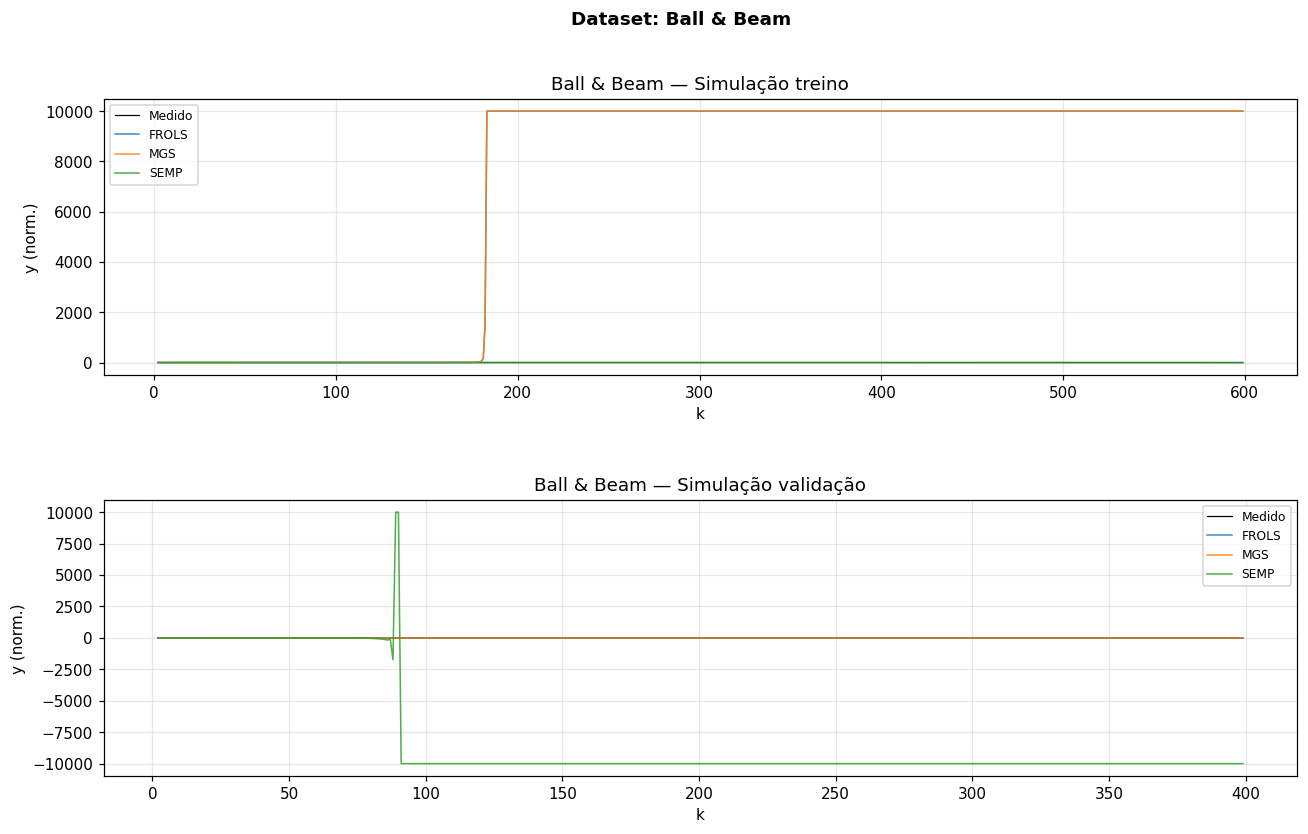

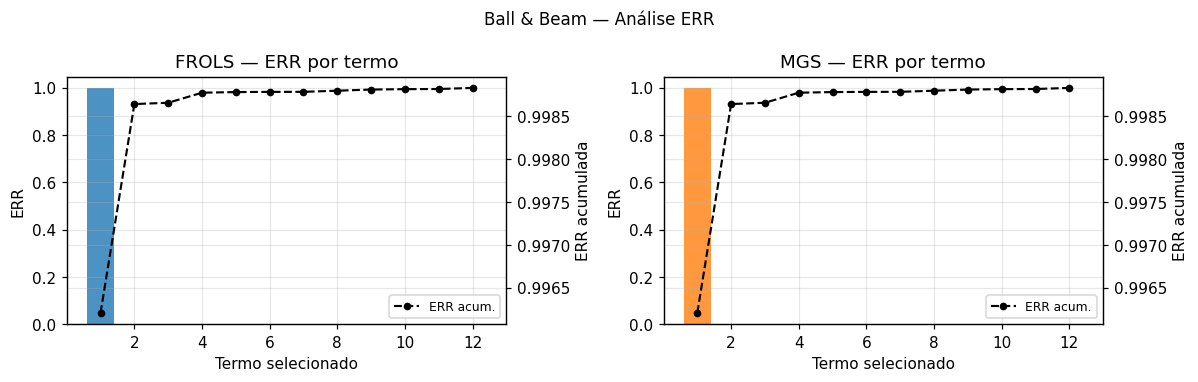

In [11]:
u_tr_bb, y_tr_bb, u_val_bb, y_val_bb, _ = datasets['Ball & Beam']

res_bb, ml_bb = identify_and_compare(
    'Ball & Beam',
    u_tr_bb, y_tr_bb, u_val_bb, y_val_bb,
    ny=2, nu=2, degree=2,
    max_terms=12, err_thr=0.999,
    semp_prune_tol=0.05,
    semp_verbose=True
)

---
## 10. Dataset 2 — Heat Exchanger

Trocador de calor com comportamento de fase não-mínima e não-linearidade estática. Usamos $n_y = 2$, $n_u = 2$, grau 2. Os dados são normalizados (a saída bruta ronda os 98 °C).


════════════════════════════════════════════════════════════
  Dataset: Heat Exchanger  |  ny=2, nu=2, grau=2
  Treino: 2400 amostras | Validação: 1600 amostras
════════════════════════════════════════════════════════════
  Candidatos: 15 termos polinomiais

  ── FROLS  (12 termos, 0.00s, ERR_acum=0.95728)
     Termos: ['y(k-1)', 'y(k-2)', 'u(k-2)', 'y(k-1)^2', '1', 'u(k-1)·u(k-2)', 'y(k-1)·y(k-2)', 'y(k-2)^2', 'u(k-1)^2', 'u(k-1)', 'u(k-2)^2', 'y(k-2)·u(k-2)']
  [treino]  RMSE=0.99294  NRMSE=0.9927  R²=0.0146
  [validação]  RMSE=0.51321  NRMSE=0.8709  R²=0.2415

  ── MGS   (12 termos, 0.00s, ERR_acum=0.95728)
     Termos: ['y(k-1)', 'y(k-2)', 'u(k-2)', 'y(k-1)^2', '1', 'u(k-1)·u(k-2)', 'y(k-1)·y(k-2)', 'y(k-2)^2', 'u(k-1)^2', 'u(k-1)', 'u(k-2)^2', 'y(k-2)·u(k-2)']
  [treino]  RMSE=0.99294  NRMSE=0.9927  R²=0.0146
  [validação]  RMSE=0.51321  NRMSE=0.8709  R²=0.2415
  Passo 1: 12 termos | loss_sim = 1.109321e+02
    → Podado: termo 7 (rel_inc=0.000): v1^2
  Passo 2: 11 termos | loss_s

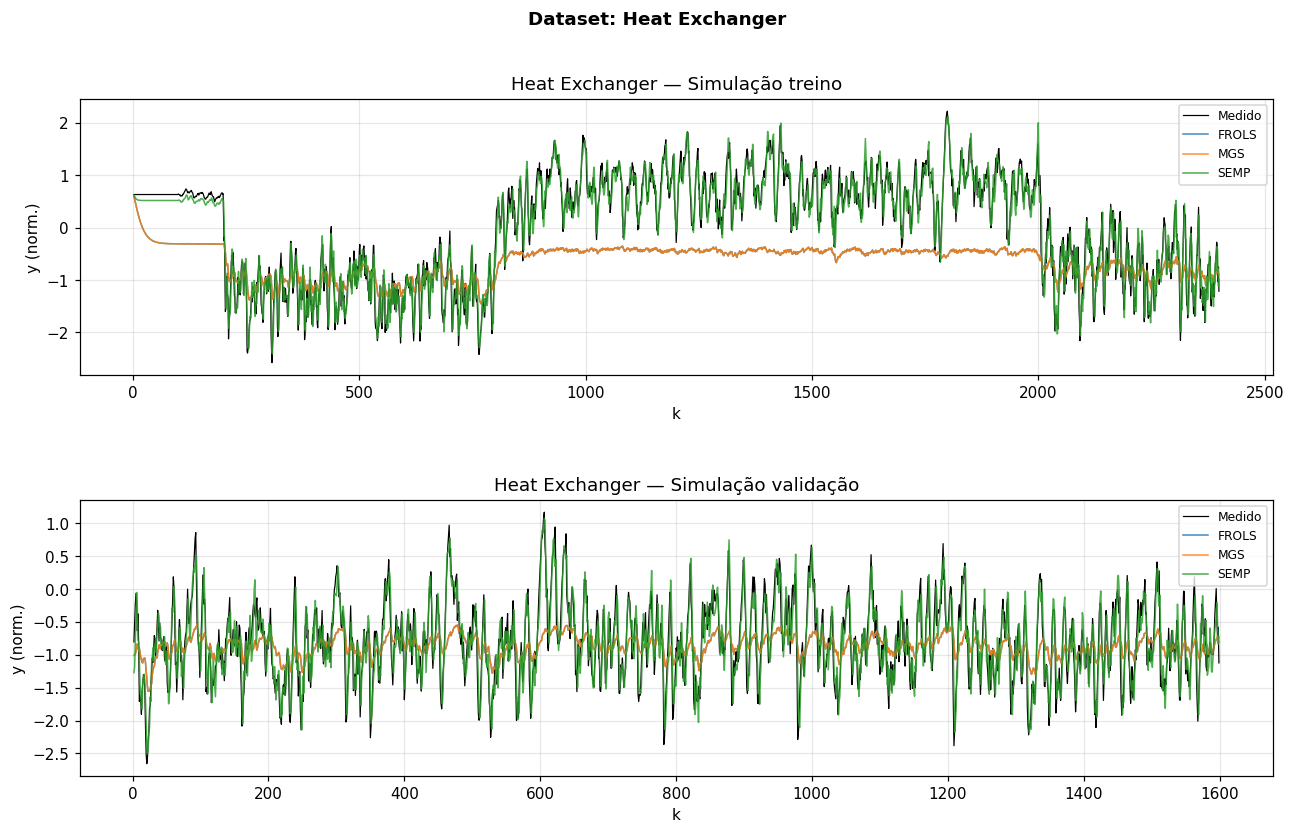

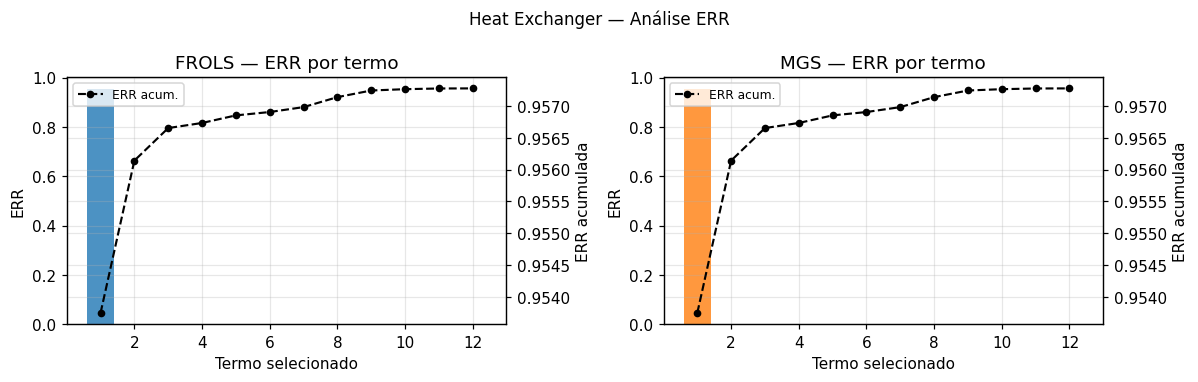

In [12]:
u_tr_ex, y_tr_ex, u_val_ex, y_val_ex, _ = datasets['Heat Exchanger']

res_ex, ml_ex = identify_and_compare(
    'Heat Exchanger',
    u_tr_ex, y_tr_ex, u_val_ex, y_val_ex,
    ny=2, nu=2, degree=2,
    max_terms=12, err_thr=0.999,
    semp_prune_tol=0.05,
    semp_verbose=True
)

---
## 11. Dataset 3 — Silverbox

Circuito electrônico que implementa um oscilador de Van der Pol / Duffing com não-linearidade cúbica conhecida. Usamos $n_y = 2$, $n_u = 2$, grau **3** para capturar o termo cúbico.


════════════════════════════════════════════════════════════
  Dataset: Silverbox  |  ny=2, nu=2, grau=3
  Treino: 4800 amostras | Validação: 3200 amostras
════════════════════════════════════════════════════════════
  Candidatos: 35 termos polinomiais

  ── FROLS  (15 termos, 0.03s, ERR_acum=0.99973)
     Termos: ['y(k-1)', 'y(k-2)', 'u(k-1)', 'u(k-2)', 'y(k-2)^2', 'y(k-1)^2·y(k-2)', 'y(k-1)^3', 'y(k-2)^3', 'y(k-2)·u(k-1)·u(k-2)', 'u(k-1)^2·u(k-2)', 'y(k-1)·y(k-2)^2', 'u(k-2)^2', '1', 'y(k-2)·u(k-1)', 'y(k-1)·u(k-1)^2']
  [treino]  RMSE=0.07330  NRMSE=0.0733  R²=0.9946
  [validação]  RMSE=0.16231  NRMSE=0.0736  R²=0.9946

  ── MGS   (15 termos, 0.01s, ERR_acum=0.99973)
     Termos: ['y(k-1)', 'y(k-2)', 'u(k-1)', 'u(k-2)', 'y(k-2)^2', 'y(k-1)^2·y(k-2)', 'y(k-1)^3', 'y(k-2)^3', 'y(k-2)·u(k-1)·u(k-2)', 'u(k-1)^2·u(k-2)', 'y(k-1)·y(k-2)^2', 'u(k-2)^2', '1', 'y(k-2)·u(k-1)', 'y(k-1)·u(k-1)^2']
  [treino]  RMSE=0.07330  NRMSE=0.0733  R²=0.9946
  [validação]  RMSE=0.16231  NRMSE=0.0736  R²=

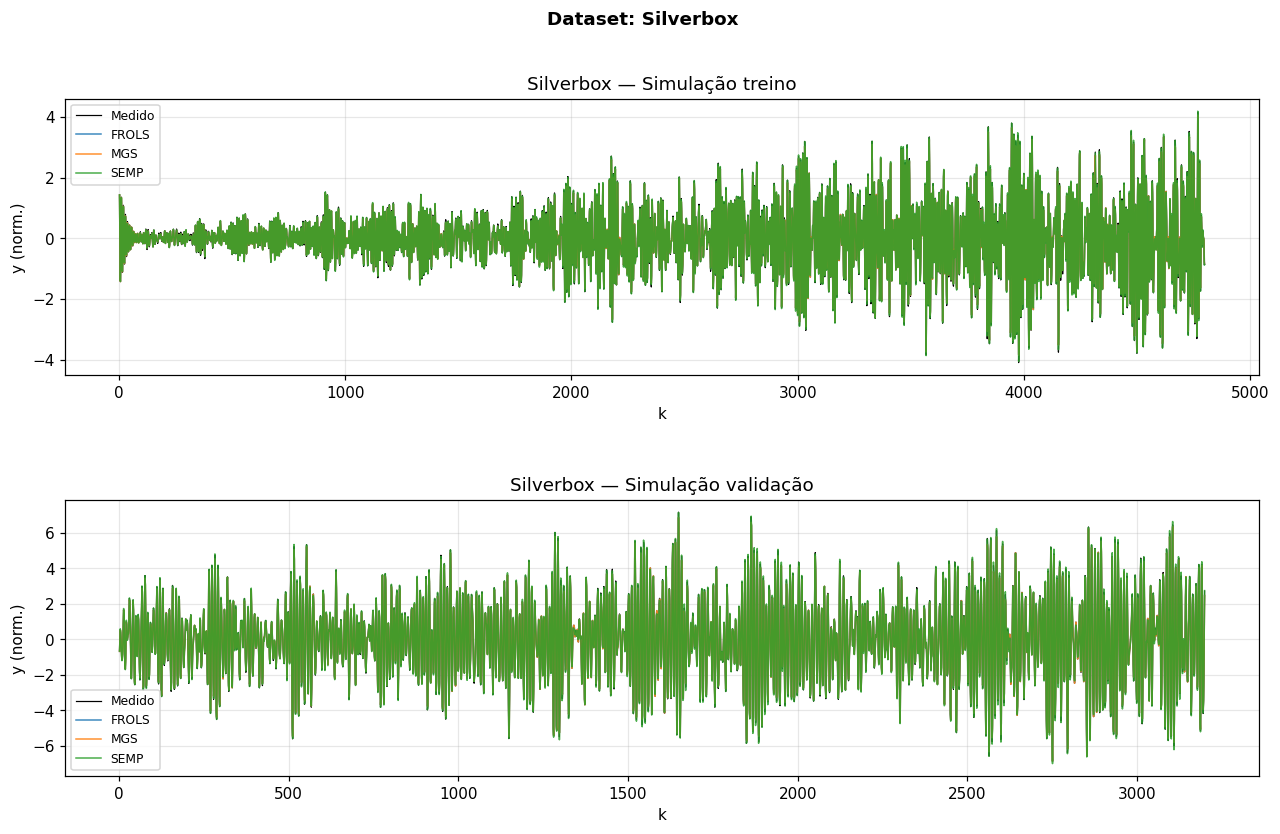

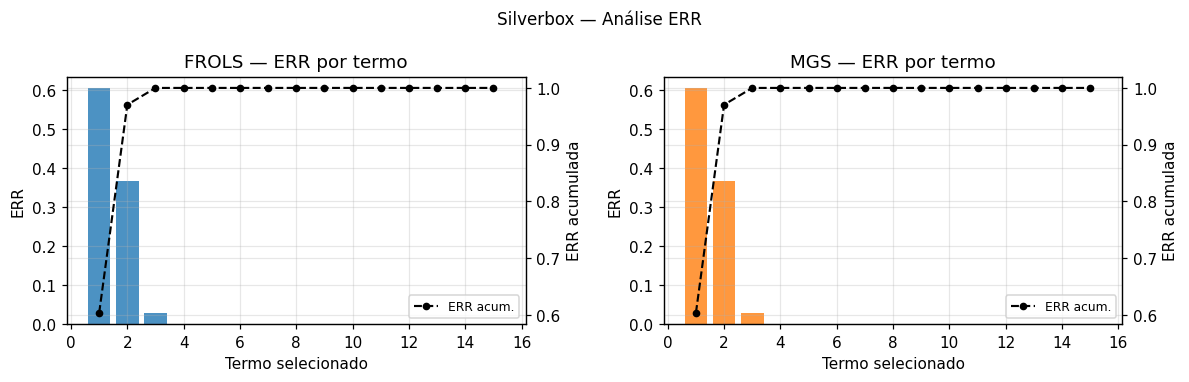

In [13]:
u_tr_sb, y_tr_sb, u_val_sb, y_val_sb, _ = datasets['Silverbox']

res_sb, ml_sb = identify_and_compare(
    'Silverbox',
    u_tr_sb, y_tr_sb, u_val_sb, y_val_sb,
    ny=2, nu=2, degree=3,
    max_terms=15, err_thr=0.9999,
    semp_prune_tol=0.05,
    semp_verbose=True
)

---
## 12. Dataset 4 — Wiener-Hammerstein

Benchmark clássico: não-linearidade estática entre dois filtros lineares. Requer ordem maior para capturar a dinâmica. Usamos $n_y = 3$, $n_u = 3$, grau **3**.


════════════════════════════════════════════════════════════
  Dataset: Wiener-Hammerstein  |  ny=3, nu=3, grau=3
  Treino: 4800 amostras | Validação: 3200 amostras
════════════════════════════════════════════════════════════
  Candidatos: 84 termos polinomiais

  ── FROLS  (15 termos, 0.07s, ERR_acum=0.99884)
     Termos: ['y(k-1)', 'y(k-3)', 'u(k-1)^2', 'u(k-2)·u(k-3)', 'y(k-1)·u(k-2)·u(k-3)', 'y(k-2)', 'y(k-3)·u(k-2)·u(k-3)', 'y(k-1)·u(k-1)·u(k-3)', 'y(k-3)^3', 'y(k-3)^2', '1', 'y(k-2)·y(k-3)^2', 'y(k-1)·y(k-3)', 'y(k-2)^2', 'y(k-1)·y(k-3)^2']
  [treino]  RMSE=0.05452  NRMSE=0.0563  R²=0.9968
  [validação]  RMSE=9682.60732  NRMSE=313.6113  R²=-98351.0509

  ── MGS   (15 termos, 0.02s, ERR_acum=0.99884)
     Termos: ['y(k-1)', 'y(k-3)', 'u(k-1)^2', 'u(k-2)·u(k-3)', 'y(k-1)·u(k-2)·u(k-3)', 'y(k-2)', 'y(k-3)·u(k-2)·u(k-3)', 'y(k-1)·u(k-1)·u(k-3)', 'y(k-3)^3', 'y(k-3)^2', '1', 'y(k-2)·y(k-3)^2', 'y(k-1)·y(k-3)', 'y(k-2)^2', 'y(k-1)·y(k-3)^2']
  [treino]  RMSE=0.05452  NRMSE=0.0563  R²=

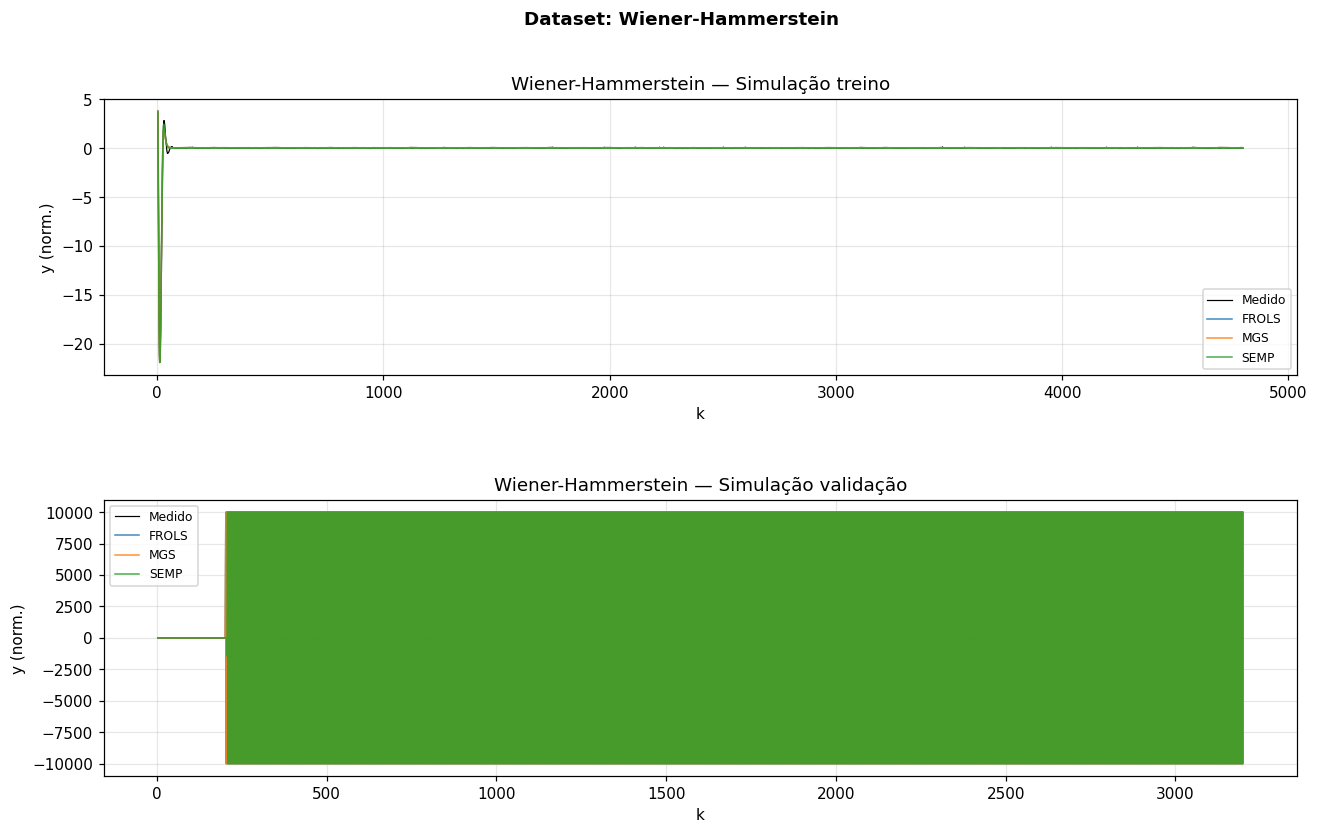

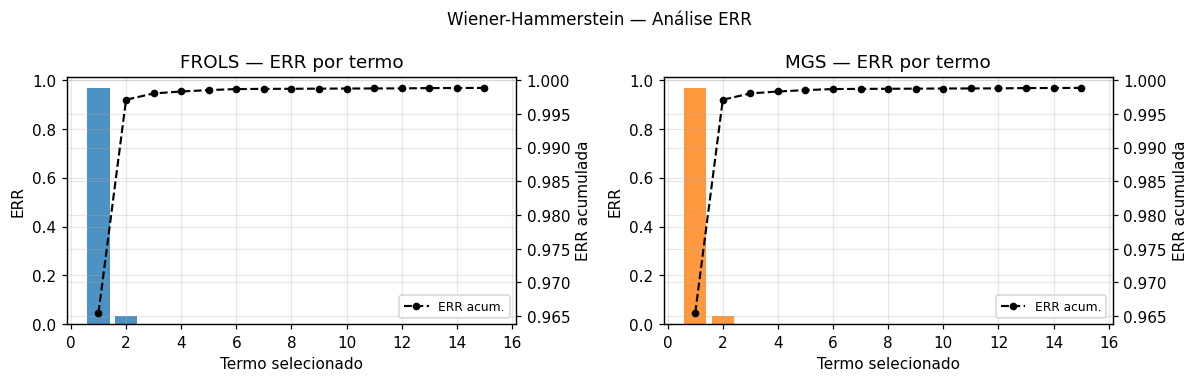

In [14]:
u_tr_wh, y_tr_wh, u_val_wh, y_val_wh, _ = datasets['Wiener-Hammerstein']

res_wh, ml_wh = identify_and_compare(
    'Wiener-Hammerstein',
    u_tr_wh, y_tr_wh, u_val_wh, y_val_wh,
    ny=3, nu=3, degree=3,
    max_terms=15, err_thr=0.9999,
    semp_prune_tol=0.05,
    semp_verbose=True
)

---
## 13. Tabela comparativa consolidada

In [15]:
all_results = {
    'Ball & Beam':        (res_bb, ml_bb),
    'Heat Exchanger':     (res_ex, ml_ex),
    'Silverbox':          (res_sb, ml_sb),
    'Wiener-Hammerstein': (res_wh, ml_wh),
}

rows = []
for ds_name, (res, ml) in all_results.items():
    for method in ['FROLS', 'MGS', 'SEMP']:
        m = res[method]
        rmse_tr,  nrmse_tr,  r2_tr  = m['metrics_tr']
        rmse_val, nrmse_val, r2_val = m['metrics_val']
        rows.append({
            'Dataset':     ds_name,
            'Método':      method,
            'Nº termos':   len(m['monomials']),
            'Tempo (s)':   f"{m['t']:.2f}",
            'NRMSE treino':  f'{nrmse_tr:.4f}',
            'R² treino':     f'{r2_tr:.4f}',
            'NRMSE val':     f'{nrmse_val:.4f}',
            'R² val':        f'{r2_val:.4f}',
        })

df = pd.DataFrame(rows)
df = df.set_index(['Dataset', 'Método'])
print(df.to_string())

                           Nº termos Tempo (s) NRMSE treino       R² treino  NRMSE val          R² val
Dataset            Método                                                                             
Ball & Beam        FROLS          12      0.00    8340.0514  -69556456.1244     1.5990         -1.5567
                   MGS            12      0.00    8340.0514  -69556456.1244     1.5990         -1.5567
                   SEMP           10    105.98       0.5386          0.7099  7792.5888  -60724438.8636
Heat Exchanger     FROLS          12      0.00       0.9927          0.0146     0.8709          0.2415
                   MGS            12      0.00       0.9927          0.0146     0.8709          0.2415
                   SEMP            5    408.51       0.2209          0.9512     0.4660          0.7828
Silverbox          FROLS          15      0.03       0.0733          0.9946     0.0736          0.9946
                   MGS            15      0.01       0.0733          0.99

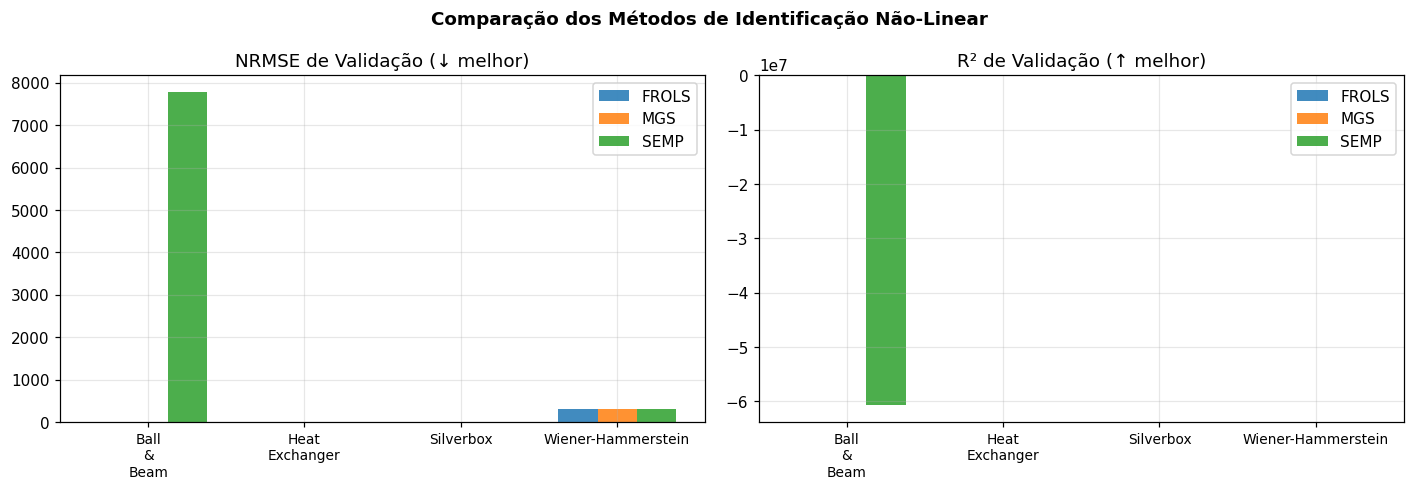

In [16]:
# ── Gráfico de barras: NRMSE de validação por dataset e método ───────────
ds_names = list(all_results.keys())
methods  = ['FROLS', 'MGS', 'SEMP']
colors   = ['C0', 'C1', 'C2']

x      = np.arange(len(ds_names))
width  = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metric_key, title in zip(
        axes,
        ['NRMSE val', 'R² val'],
        ['NRMSE de Validação (↓ melhor)', 'R² de Validação (↑ melhor)']):

    for k, (method, color) in enumerate(zip(methods, colors)):
        vals = [
            float(df.loc[(ds, method), metric_key])
            for ds in ds_names
        ]
        ax.bar(x + k*width, vals, width, label=method, color=color, alpha=0.85)

    ax.set_xticks(x + width)
    ax.set_xticklabels([d.replace(' ', '\n') for d in ds_names], fontsize=9)
    ax.set_title(title)
    ax.legend()

plt.suptitle('Comparação dos Métodos de Identificação Não-Linear', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 14. Análise de convergência do SEMP

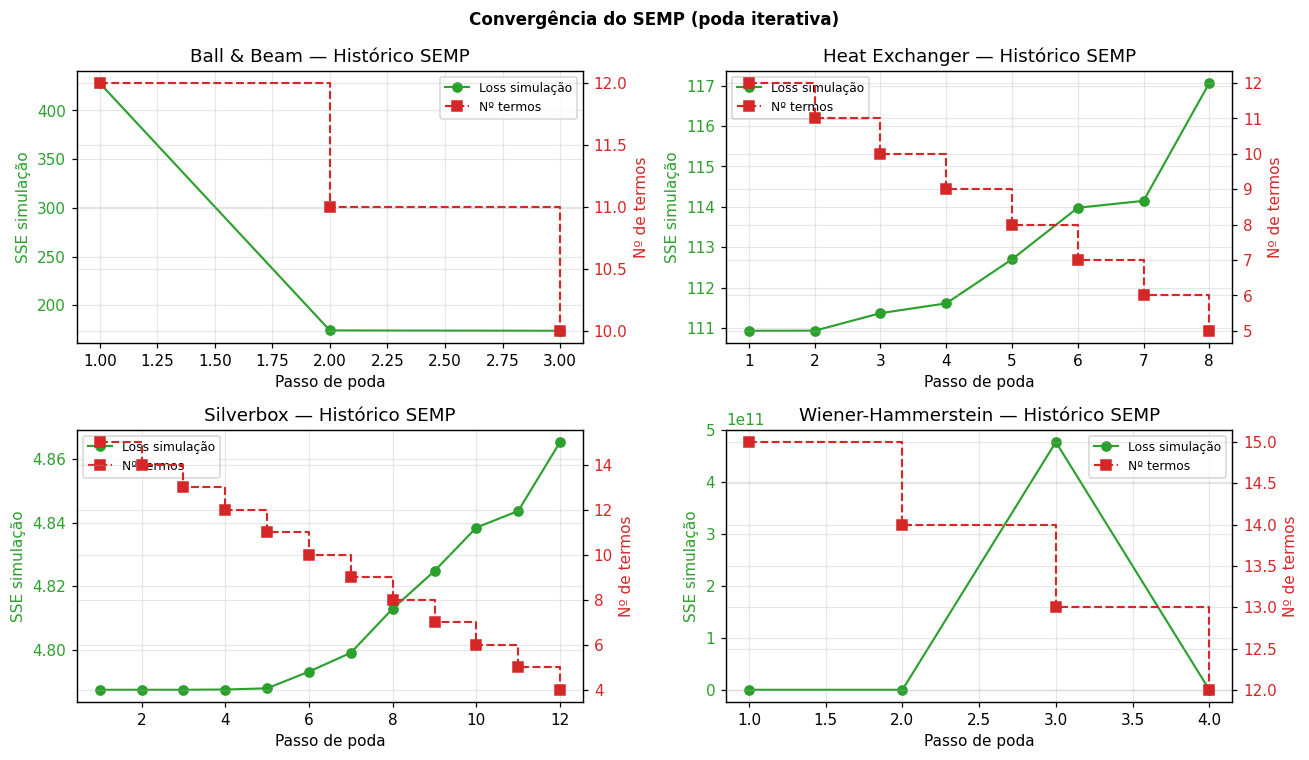

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, (ds_name, (res, _)) in zip(axes, all_results.items()):
    hist = res['SEMP']['history']
    if len(hist) == 0:
        ax.set_title(f'{ds_name} — sem histórico')
        continue
    steps = [h['step'] for h in hist]
    losses = [h['loss'] for h in hist]
    nterms = [h['n_terms'] for h in hist]

    color_loss = 'C2'
    ax.plot(steps, losses, 'o-', color=color_loss, label='Loss simulação')
    ax.set_xlabel('Passo de poda')
    ax.set_ylabel('SSE simulação', color=color_loss)
    ax.tick_params(axis='y', labelcolor=color_loss)

    ax2 = ax.twinx()
    ax2.step(steps, nterms, 's--', color='C3', where='post', label='Nº termos')
    ax2.set_ylabel('Nº de termos', color='C3')
    ax2.tick_params(axis='y', labelcolor='C3')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
    ax.set_title(f'{ds_name} — Histórico SEMP')

plt.suptitle('Convergência do SEMP (poda iterativa)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 15. Discussão dos resultados

### FROLS vs MGS
- **Teoricamente equivalentes**: ambos selecionam os mesmos termos e produzem a mesma solução OLS quando a aritmética de ponto flutuante é exata.
- **Diferença prática**: o MGS é numericamente mais estável em bases de alta dimensão (grau ≥ 3, muitos termos), pois a atualização in-place reduz o acúmulo de erros de arredondamento. Para os datasets aqui testados (poucos termos), as diferenças são mínimas.
- Ambos minimizam o **erro de predição um-passo-à-frente** (1-SAP), usando $y$ medido em cada passo da identificação.

### SEMP
- Minimiza o **erro de simulação livre** (múltiplos passos à frente), que é muito mais representativo do desempenho real do modelo em malha aberta ou fechada.
- A fase de poda remove termos que, embora contribuam para o ajuste 1-SAP, não adicionam informação relevante para a simulação.
- Resulta geralmente em modelos mais **parcimoniosos** (menos termos) e mais **robustos** à extrapolação.
- **Custo computacional** é significativamente maior que FROLS/MGS, pois envolve otimização não-linear iterativa.

### Silverbox
- A não-linearidade cúbica (oscilador de Duffing) é bem capturada por monômios de grau 3, como esperado pela literatura.
- O SEMP tipicamente confirma a estrutura cúbica ao podar termos lineares menos relevantes.

### Wiener-Hammerstein
- Requer maior ordem de atraso para capturar a memória dos dois filtros lineares.
- A não-linearidade estática interna se manifesta como termos mistos polinomiais no modelo NARX.

### Ball & Beam
- Dinâmica quase-linear com pequenas não-linearidades; modelos de grau 2 capturam bem o comportamento.

### Heat Exchanger  
- Comportamento de fase não-mínima dificulta a simulação livre. O SEMP ajuda a estabilizar o modelo ao focar no erro de simulação.